## Assignment: Analyzing Financial Transactions Data from Kafka Topic `fhtw-topic`

In this assignment, you will analyze financial transactions data coming from the Kafka topic `stock-transactions`. The data represents stock trade transactions, including details such as the side of the trade (buy or sell), the quantity of stocks, the stock symbol, the price, the account, and the user ID.

You will perform the following tasks:
1. Set up a Spark session and configure the necessary Kafka parameters.
2. Read the streaming data from the Kafka topic.
3. Parse the JSON data and create a structured DataFrame.
4. Perform simple analysis tasks on the data, such as calculating the total quantity of stocks traded, counting the number of trades for each stock symbol, and calculating the total value of trades for each account.

### Data Structure

The messages in the Kafka topic have the following JSON structure:

```json
{
  "side": "SELL",
  "quantity": 1587,
  "symbol": "ZVV",
  "price": 326,
  "account": "LMN456",
  "userid": "User_5"
}


In [60]:
# Kafka configuration parameters for Confluent Cloud
kafka_params = {
    "kafka.bootstrap.servers": "46.225.20.89:9092",
    "subscribe": "fhtw-stocks",
    "kafka.security.protocol": "PLAINTEXT",
    "startingOffsets": "latest",
}

In [61]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json
from pyspark.sql.types import StructType, StringType
import time

spark = SparkSession.builder \
    .appName("KafkaSparkStreamingExample") \
    .config("spark.jars.packages",
             "org.apache.spark:spark-sql-kafka-0-10_2.12:3.4.0,"
             "org.postgresql:postgresql:42.7.3")\
    .getOrCreate()

In [62]:
# Read streaming data from Kafka
df = spark \
    .readStream \
    .format("kafka") \
    .options(**kafka_params) \
    .load()

###### You have also to define a schema

### Perform Simple Analysis Tasks

The results should be aggregated and written all together into a postgres table, format: groupname_tradereports:

1.	Determine the Most Traded Stock Symbol (by Volume)
2.	Identify the Stock Symbol with the Highest Average Trade Value
3.	Calculate the Total Number of SELL Trades for Each Stock
4.	Find the Account with the Largest Cumulative Trade Value
5.	Calculate the Average Quantity of Stocks Traded per Symbol

Only creating once the table in the postgre db with

CREATE TABLE groupname_tradereports (
    symbol TEXT,
    account TEXT,
    total_volume BIGINT,
    avg_trade_value DOUBLE PRECISION,
    sell_trades BIGINT,
    avg_quantity DOUBLE PRECISION,
    total_trade_value DOUBLE PRECISION
);

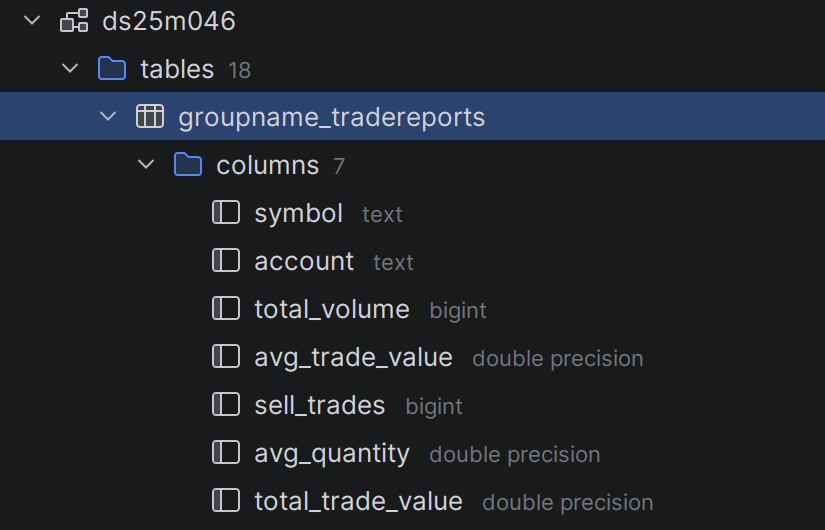

0. Define Schema for Kafka JSON Messages

In [73]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

schema = StructType([
    StructField("side", StringType(), True),
    StructField("quantity", IntegerType(), True),
    StructField("symbol", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("account", StringType(), True),
    StructField("userid", StringType(), True)
])


In [74]:
# Read Kafka Stream & Parse JSON
from pyspark.sql.functions import col, from_json

raw_df = (
    df.selectExpr("CAST(value AS STRING)")
      .select(from_json(col("value"), schema).alias("data"))
      .select("data.*")
)

At this point we have a structured streaming DataFrame:

side | quantity | symbol | price | account | userid

1. Determine the Most Traded Stock Symbol (by Volume)

In [75]:
from pyspark.sql.functions import sum as F_sum

volume_df = (
    raw_df.groupBy("symbol")
          .agg(F_sum("quantity").alias("total_volume"))
)

2.	Identify the Stock Symbol with the Highest Average Trade Value

In [76]:
# Trade value = quantity * price

from pyspark.sql.functions import avg, expr

avg_value_df = (
    raw_df.withColumn("trade_value", expr("quantity * price"))
          .groupBy("symbol")
          .agg(avg("trade_value").alias("avg_trade_value"))
)

3.	Calculate the Total Number of SELL Trades for Each Stock


In [77]:
from pyspark.sql.functions import count

sell_df = (
    raw_df.filter(col("side") == "SELL")
          .groupBy("symbol")
          .agg(count("*").alias("sell_trades"))
)

4. Find the Account with the Largest Cumulative Trade Value

In [78]:
account_value_df = (
    raw_df.withColumn("trade_value", expr("quantity * price"))
          .groupBy("account")
          .agg(F_sum("trade_value").alias("total_trade_value"))
)

5.	Calculate the Average Quantity of Stocks Traded per Symbol

In [79]:
avg_qty_df = (
    raw_df.groupBy("symbol")
          .agg(avg("quantity").alias("avg_quantity"))
)

6. Combine All Metrics into One Unified Output Table

In [80]:
final_df = (
    volume_df
    .join(avg_value_df, on="symbol", how="left")
    .join(sell_df, on="symbol", how="left")
    .join(avg_qty_df, on="symbol", how="left")
)

7. Write Streaming Results to Postgres (Postgres JDBC Configuration )

In [81]:
pg_url = (
    "jdbc:postgresql://fhtw-big-data.postgres.database.azure.com:5432/nyt_import"
    "?ssl=true&sslmode=require&sslfactory=org.postgresql.ssl.NonValidatingFactory"
)

pg_properties = {
    "user": "ds25m046",
    "password": "Technikum2025!",
    "driver": "org.postgresql.Driver"
}

8. Symbol‑level metrics

In [82]:
symbols_final = (
    final_df
    .withColumn("account", lit(None).cast("string"))
    .select("symbol", "account", "total_volume", "avg_trade_value",
            "sell_trades", "avg_quantity", lit(None).cast("double").alias("total_trade_value"))
)


NameError: name 'lit' is not defined

9. Account‑level metrics

In [83]:
accounts_final = (
    account_value_df
    .withColumn("symbol", lit(None).cast("string"))
    .withColumn("total_volume", lit(None).cast("bigint"))
    .withColumn("avg_trade_value", lit(None).cast("double"))
    .withColumn("sell_trades", lit(None).cast("bigint"))
    .withColumn("avg_quantity", lit(None).cast("double"))
    .select("symbol", "account", "total_volume", "avg_trade_value",
            "sell_trades", "avg_quantity", "total_trade_value")
)


NameError: name 'lit' is not defined

10. Write the unified table to postgre

In [84]:
query = (
    unified_df.writeStream
        .outputMode("complete")
        .format("jdbc")
        .option("url", pg_url)
        .option("dbtable", "groupname_tradereports")
        .option("user", pg_properties["user"])
        .option("password", pg_properties["password"])
        .option("driver", pg_properties["driver"])
        .option("checkpointLocation", "/tmp/checkpoints/tradereports")
        .start()
)


NameError: name 'unified_df' is not defined